# Forecasting Demo - SARIMA baseline + Prophet CI; XGBoost no CI
- Synthetic daily sales
- Models: SARIMA (statistical baseline with CI), Prophet (with CI), XGBoost (no CI)
- Individual plots per model: in-sample fit (backtest) + out-of-sample forecast
- 
Requirements: pandas, numpy, matplotlib, sklearn, xgboost, prophet, statsmodels


In [66]:
## Libraries

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
import xgboost as xgb

# Prophet import: try modern name, fallback to fbprophet
try:
    from prophet import Prophet
except Exception:
    from fbprophet import Prophet

from statsmodels.tsa.statespace.sarimax import SARIMAX
    

In [67]:
## Data
SEED = 42
np.random.seed(SEED)

def generate_synthetic_sales(start='2020-01-01', periods=900):
    dates = pd.date_range(start, periods=periods, freq='D')
    t = np.arange(periods)
    trend = 0.02 * t
    seasonal = 10 * np.sin(2 * np.pi * t / 7) + 20 * np.sin(2 * np.pi * t / 365.25)
    noise = np.random.normal(scale=5.0, size=periods)
    baseline = 50
    sales = np.maximum(0, baseline + trend + seasonal + noise).round(2)
    return pd.DataFrame({'ds': dates, 'y': sales})

def train_test_split_ts(df, h=30):
    train = df.iloc[:-h].reset_index(drop=True)
    test = df.iloc[-h:].reset_index(drop=True)
    return train, test

In [68]:
# Metrics 
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1e-9, y_true))) * 100
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'WMAPE(%)': wmape}

In [69]:
# Training
def fit_sarima(train, test, order=(1,1,1), seasonal_order=(1,1,1,7)):
    """
    Fit a SARIMAX on `train` and return:
      - fitted result object
      - in-sample predicted mean (numpy array, length = len(train))
      - out-of-sample predicted mean (numpy array, length = len(test))
      - lower and upper 95% CI arrays for the forecast (numpy arrays, length = len(test))
    This implementation is robust to statsmodels returning DataFrame or ndarray.
    """
    y = train['y'].values
    model = SARIMAX(endog=y, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)

    # In-sample fitted values: get_prediction covers fitted / one-step-ahead
    in_sample_pred_obj = res.get_prediction(start=0, end=len(train)-1)
    train_pred = in_sample_pred_obj.predicted_mean
    train_pred = np.asarray(train_pred)  # ensure numpy array

    # Forecast
    fc = res.get_forecast(steps=len(test))
    test_pred = fc.predicted_mean
    test_pred = np.asarray(test_pred)

    # Confidence interval (statsmodels may return DataFrame or ndarray)
    conf_int = fc.conf_int(alpha=0.05)
    if isinstance(conf_int, pd.DataFrame):
        lower = conf_int.iloc[:, 0].values
        upper = conf_int.iloc[:, 1].values
    else:
        # assume ndarray with shape (steps, 2)
        lower = np.asarray(conf_int)[:, 0]
        upper = np.asarray(conf_int)[:, 1]

    return res, train_pred, test_pred, lower, upper

# Prophet: returns model, full forecast dataframe, train preds (in-sample), test preds (out-of-sample)
def fit_prophet(train, test, seasonality_mode='additive'):
    m = Prophet(seasonality_mode=seasonality_mode, daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
    m.fit(train[['ds','y']])
    future = m.make_future_dataframe(periods=len(test), freq='D')
    fcst = m.predict(future)
    train_preds = fcst[['ds','yhat']].iloc[:len(train)]['yhat'].values
    test_preds = fcst[['ds','yhat']].iloc[-len(test):]['yhat'].values
    return m, fcst, train_preds, test_preds

# XGBoost with lag features (no CI)
def make_lag_features(df, lags=[1,7,14]):
    df = df.copy()
    for lag in lags:
        df[f'lag_{lag}'] = df['y'].shift(lag)
    df['dayofweek'] = df['ds'].dt.dayofweek
    df['dayofmonth'] = df['ds'].dt.day
    df['month'] = df['ds'].dt.month
    return df

def fit_xgb(train, test, lags=[1,7,14]):
    combined = pd.concat([train, test]).reset_index(drop=True)
    combined = make_lag_features(combined, lags=lags)
    train_feat = combined.iloc[:len(train)].dropna().reset_index(drop=True)
    feats = [c for c in train_feat.columns if c not in ['ds','y']]
    model = xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=SEED, verbosity=0)
    model.fit(train_feat[feats], train_feat['y'])
    # in-sample preds aligned to train dates (NaN where lags not available)
    train_preds_full = pd.Series(index=train['ds'], dtype=float)
    train_preds_full[:] = np.nan
    train_pred_vals = model.predict(train_feat[feats])
    train_preds_full.iloc[len(train)-len(train_pred_vals):] = train_pred_vals
    # iterative forecasting for test
    preds = []
    buffer = train[['ds','y']].copy().reset_index(drop=True)
    for i in range(len(test)):
        current_date = test['ds'].iloc[i]
        row = {'ds': current_date}
        for lag in lags:
            row[f'lag_{lag}'] = buffer['y'].iloc[-lag]
        row['dayofweek'] = current_date.dayofweek
        row['dayofmonth'] = current_date.day
        row['month'] = current_date.month
        xrow = pd.DataFrame([row])
        xrow = xrow[feats]
        pred = model.predict(xrow)[0]
        preds.append(pred)
        new_row = pd.DataFrame({'ds': [current_date], 'y': [pred]})
        buffer = pd.concat([buffer, new_row], ignore_index=True)
    return train_preds_full.values, np.array(preds)

In [70]:
# Plotting
# single-model plotting (SARIMA & Prophet include CI, XGBoost no CI)
def plot_model_individual(name, train_df, test_df, train_pred, test_pred, lower_test=None, upper_test=None, train_pred_label='in-sample pred'):
    plt.figure(figsize=(12,4))
    plt.plot(train_df['ds'], train_df['y'], label='train actual', color='black', alpha=0.6)
    plt.plot(train_df['ds'], train_pred, label=train_pred_label, color='tab:orange', linestyle='--')
    plt.plot(test_df['ds'], test_df['y'], label='test actual', color='black', linestyle='--')
    plt.plot(test_df['ds'], test_pred, label='forecast', color='tab:blue')
    if (lower_test is not None) and (upper_test is not None):
        plt.fill_between(test_df['ds'], lower_test, upper_test, color='tab:blue', alpha=0.2, label='95% CI')
    plt.title(f'Model: {name} — in-sample fit (backtest) + forecast')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.tight_layout()
    plt.show()


18:57:11 - cmdstanpy - INFO - Chain [1] start processing
18:57:11 - cmdstanpy - INFO - Chain [1] done processing


SARIMA metrics: {'MAE': 3.701617281691044, 'RMSE': 4.443365501311003, 'MAPE(%)': np.float64(4.876552728069082), 'WMAPE(%)': np.float64(4.737382884220798)}
Prophet metrics: {'MAE': 2.718606172590994, 'RMSE': 3.327655087116203, 'MAPE(%)': np.float64(3.4689187757426723), 'WMAPE(%)': np.float64(3.4793111688429113)}
XGBoost metrics: {'MAE': 5.423577590942382, 'RMSE': 6.222949594491512, 'MAPE(%)': np.float64(6.813995805986918), 'WMAPE(%)': np.float64(6.941172383665791)}


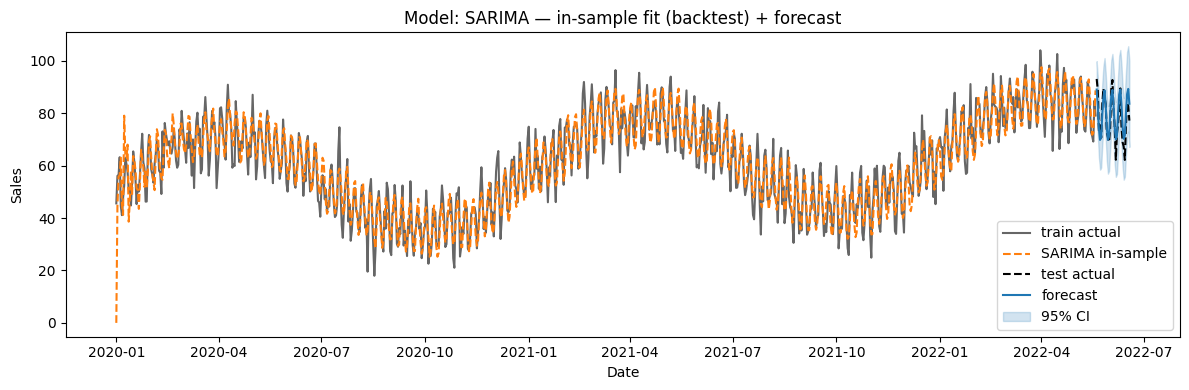

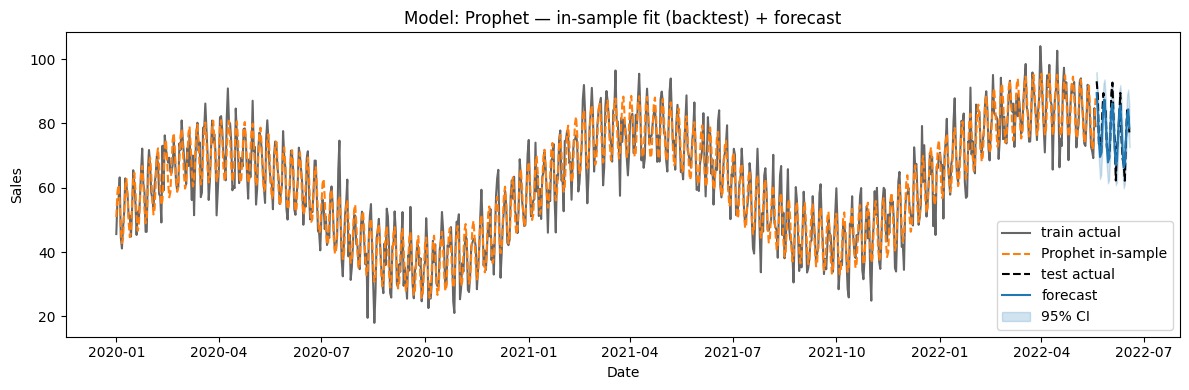

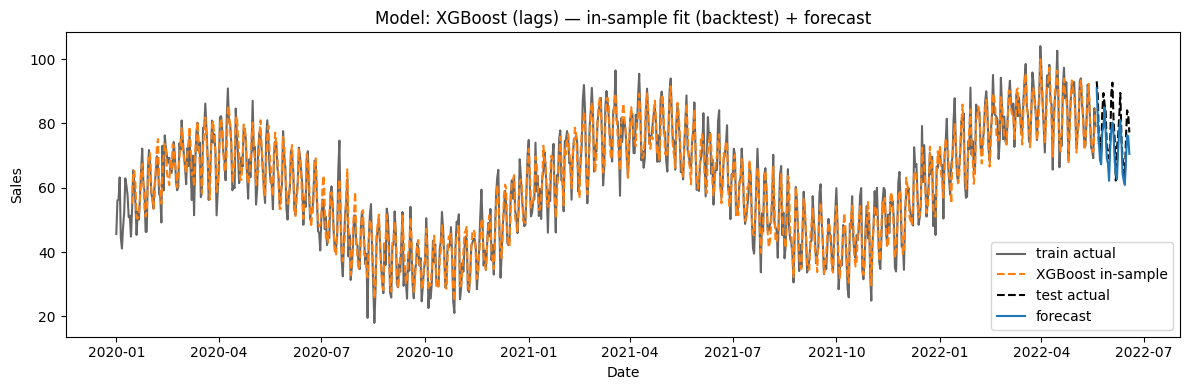

,MAE,RMSE,MAPE(%),WMAPE(%)
model,,,,
SARIMA,3.702,4.443,4.877,4.737
Prophet,2.719,3.328,3.469,3.479
XGBoost(lags),5.424,6.223,6.814,6.941


Note on confidence intervals:
- SARIMA & Prophet: produce model-based predictive intervals derived from the model's statistical assumptions and estimated parameter uncertainty.
- XGBoost: produces point predictions only and does not provide predictive intervals by default.
  To obtain intervals for ML models, options include conformal prediction, quantile regression, bootstrapping, or using an ensemble of models to estimate prediction quantiles.


In [72]:
# Executing main function

def main():
    df = generate_synthetic_sales()
    H = 30
    train, test = train_test_split_ts(df, h=H)

    # SARIMA baseline
    sar_res, sar_train_pred, sar_test_pred, sar_lower, sar_upper = fit_sarima(train, test,
                                                                              order=(1,1,1),
                                                                              seasonal_order=(1,1,1,7))
    print('SARIMA metrics:', metrics(test['y'].values, sar_test_pred))

    # Prophet (with native CI)
    prop_model, prop_full, prop_train_pred, prop_test_pred = fit_prophet(train, test)
    prop_ci = prop_full[['ds','yhat','yhat_lower','yhat_upper']].iloc[-len(test):].reset_index(drop=True)
    print('Prophet metrics:', metrics(test['y'].values, prop_test_pred))

    # XGBoost (no CI)
    xgb_train_pred, xgb_test_pred = fit_xgb(train, test, lags=[1,7,14])
    print('XGBoost metrics:', metrics(test['y'].values, xgb_test_pred))

    # Plots
    plot_model_individual('SARIMA', train, test, sar_train_pred, sar_test_pred, lower_test=sar_lower, upper_test=sar_upper, train_pred_label='SARIMA in-sample')
    plot_model_individual('Prophet', train, test, prop_train_pred, prop_test_pred,
                          lower_test=prop_ci['yhat_lower'].values, upper_test=prop_ci['yhat_upper'].values,
                          train_pred_label='Prophet in-sample')
    plot_model_individual('XGBoost (lags)', train, test, xgb_train_pred, xgb_test_pred, train_pred_label='XGBoost in-sample')

    # Summary metrics table
    preds = {'SARIMA': sar_test_pred, 'Prophet': prop_test_pred, 'XGBoost(lags)': xgb_test_pred}
    rows = []
    for name, p in preds.items():
        m = metrics(test['y'].values, p)
        m['model'] = name
        rows.append(m)
    summary = pd.DataFrame(rows).set_index('model')
    display(summary.round(3))

    # Explanation note (printed) about CIs for models
    print('Note on confidence intervals:')
    print('- SARIMA & Prophet: produce model-based predictive intervals derived from the model\'s statistical assumptions and estimated parameter uncertainty.')
    print('- XGBoost: produces point predictions only and does not provide predictive intervals by default.')
    print('  To obtain intervals for ML models, options include conformal prediction, quantile regression, bootstrapping, or using an ensemble of models to estimate prediction quantiles.')

if __name__ == '__main__':
    main()

SARIMA and Prophet produce model-based predictive intervals.
These intervals are derived from the statistical assumptions of the model and from the estimated uncertainty of its parameters.

In SARIMA, the interval comes from the estimated variance of the forecast error under the assumed stochastic process.
In Prophet, uncertainty is propagated from the trend and seasonal components into future predictions.

Therefore, the 95% intervals shown for these models reflect an explicit probabilistic framework.

XGBoost, in contrast, is a deterministic machine learning regressor.
It produces point predictions only and does not estimate a predictive distribution or forecast variance.

As a result, it does not naturally provide statistically valid confidence or predictive intervals.

To obtain uncertainty estimates for ML models, additional techniques are required, such as:

Conformal prediction

Quantile regression

Bootstrapping

Model ensembles to approximate prediction quantiles

This distinction highlights a key difference between classical statistical forecasting models and standard machine learning regressors.

We generated a time series with strong weekly and yearly seasonality, together with a positive trend component.

As expected, the naive baseline performs worst because it assumes a flat continuation of the last observed value. It does not model trend or seasonality, so forecast error increases rapidly as the prediction horizon extends.

Both Prophet and XGBoost significantly outperform the baseline, confirming that the series contains structured temporal patterns that more flexible models can capture.

Visually, Prophet and XGBoost forecasts overlap considerably. This makes it difficult to determine superiority through inspection alone and reinforces an important principle: visualization is useful for diagnosing model behavior, but objective comparison requires quantitative metrics.

When evaluated using MAE, RMSE, MAPE, and WMAPE, Prophet slightly outperforms XGBoost across all four metrics. This suggests that explicitly modeling trend and seasonal structure — as Prophet does — is particularly effective for this type of structured, periodic time series.

In contrast, XGBoost relies on engineered lag features and calendar variables to approximate temporal structure. While it performs competitively, it does not fully match Prophet’s performance in this strongly seasonal synthetic setup.

Overall, this comparison illustrates the importance of aligning model choice with the underlying data-generating process. Structured seasonal processes often favor explicitly parametric time-series models, whereas more irregular or event-driven series may benefit more from flexible machine learning approaches.